In [2]:
import os
import numpy as np
import h5py
from scipy import signal
from scipy.stats import pearsonr
import seaborn as sns
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import string

# Define path to data:
script_dir = os.path.dirname(os.path.abspath("Figure 1 Data Summary.ipynb"))
parent_dir = os.path.dirname(script_dir)
data_path = os.path.join(parent_dir, 'dfs')


In [3]:
# Load device, cshq, and sleep diary data file:
df_dreem = pd.read_csv(os.path.join(data_path, 'df_dreem_clean.csv'))
df_embrace = pd.read_csv(os.path.join(data_path, 'df_embrace_clean.csv'))
df_withings = pd.read_csv(os.path.join(data_path, 'df_withings_clean.csv'))
df_diary = pd.read_csv(os.path.join(data_path, 'df_diary_clean.csv'))
df_cshq = pd.read_csv(os.path.join(data_path, 'df_cshq_clean.csv'))

# Load subject demographics:
df_demographics = pd.read_csv(os.path.join(data_path, 'SSP_participants.csv'))

print(f"Dreem: {len(df_dreem)}, Embrace: {len(df_embrace)}, Withings: {len(df_withings)}, CSHQ: {len(df_cshq)}, Diary: {len(df_diary)}, Demographics: {len(df_demographics)}")

Dreem: 2408, Embrace: 2348, Withings: 3040, CSHQ: 200, Diary: 2624, Demographics: 200


### Limit the analysis to overlapping nights across the devices and diary


In [7]:
# merge datasets on subject and date columns:

df_dreem['date'] = pd.to_datetime(df_dreem['date'])
df_embrace['date'] = pd.to_datetime(df_embrace['date'])
df_withings['date'] = pd.to_datetime(df_withings['date'])
df_diary['date'] = pd.to_datetime(df_diary['date'])

# Merge the DataFrames on 'SPID', 'date', and 'user_type' with suffixes
merged_df = pd.merge(df_dreem, df_embrace.drop('user_type', axis=1), on=['SPID', 'date' ], suffixes=('', '_embrace'), how='inner')
merged_df = pd.merge(merged_df, df_withings.drop('user_type', axis=1), on=['SPID', 'date'], suffixes=('', '_withings'), how='inner')
merged_df = pd.merge(merged_df, df_diary.drop('user_type', axis=1), on=['SPID', 'date'], suffixes=('_dreem', '_diary'), how='inner')

# Sort the final DataFrame
merged_df = merged_df.sort_values(by=['SPID', 'date']).reset_index(drop=True)

# Count number of rows in the final DataFrame:
print(f"Number of rows in the final merged DataFrame: {len(merged_df)}")

Number of rows in the final merged DataFrame: 1193


### Remove children with less than 3 nights of data:


In [13]:
data_persub = merged_df['SPID'].value_counts()
sub_tokeep = data_persub[data_persub >= 3].index
merged_3nights = merged_df[merged_df['SPID'].isin(sub_tokeep)]

# Count number of rows in the final DataFrame:
print(f"Number of rows in the final DataFrame with at least 3 nights of data: {len(merged_3nights)}")

# Save df with all data from subjects with at least 3 nights of data:
merged_3nights.to_csv(os.path.join(data_path, 'merged_3nights.csv'),index=False)

Number of rows in the final DataFrame with at least 3 nights of data: 1151


### Organize data by sleep measure per night or per subjetct

In [9]:
TST_pernight = merged_3nights[['TST_dreem', 'TST_embrace', 'TST_withings', 'TST_diary']]
SO_pernight = merged_3nights[['SO_FromMidNight_dreem', 'SO_FromMidNight_embrace', 'SO_FromMidNight_withings', 'SO_FromMidNight_diary']]
FA_pernight = merged_3nights[['FA_FromMidNight_dreem', 'FA_FromMidNight_embrace', 'FA_FromMidNight_withings', 'FA_FromMidNight_diary']]
WASO_pernight = merged_3nights[['WASO_dreem', 'WASO_embrace', 'WASO_withings', 'WASO_diary']]

# Count number of rows in DataFrames:
print(f"Number of rows in TST_pernight: {len(TST_pernight)}, SO_pernight: {len(SO_pernight)}, FA_pernight: {len(FA_pernight)}, WASO_pernight: {len(WASO_pernight)}")

# Compute the average per SPID for selected sleep measures:
TST_bysub = merged_3nights[['SPID','TST_dreem', 'TST_embrace', 'TST_withings', 'TST_diary']].groupby('SPID').mean()
SO_bysub = merged_3nights[['SPID','SO_FromMidNight_dreem', 'SO_FromMidNight_embrace', 'SO_FromMidNight_withings', 'SO_FromMidNight_diary']].groupby('SPID').mean()
FA_bysub = merged_3nights[['SPID','FA_FromMidNight_dreem', 'FA_FromMidNight_embrace', 'FA_FromMidNight_withings', 'FA_FromMidNight_diary']].groupby('SPID').mean()
WASO_bysub = merged_3nights[['SPID','WASO_dreem', 'WASO_embrace', 'WASO_withings', 'WASO_diary']].groupby('SPID').mean()

# Organize cshq data and then merge it according to ID:

# Select only TST, WASO, SO_FromMidNight, and FA_FromMidNight columns from df_cshq:
df_cshq = df_cshq[['SPID', 'TST', 'WASO', 'SO_FromMidNight', 'FA_FromMidNight']]

# Merge with suffixes
TST_bysub = TST_bysub.merge(df_cshq[['SPID', 'TST']], on='SPID', how='inner', suffixes=('', '_cshq'))
SO_bysub = SO_bysub.merge(df_cshq[['SPID', 'SO_FromMidNight']], on='SPID', how='inner', suffixes=('', '_cshq'))
FA_bysub = FA_bysub.merge(df_cshq[['SPID', 'FA_FromMidNight']], on='SPID', how='inner', suffixes=('', '_cshq'))
WASO_bysub = WASO_bysub.merge(df_cshq[['SPID', 'WASO']], on='SPID', how='inner', suffixes=('', '_cshq'))


Number of rows in TST_pernight: 1151, SO_pernight: 1151, FA_pernight: 1151, WASO_pernight: 1151


In [ ]:
TST_demog = TST_bysub.merge(df_demographics[['SPID','sex', 'asd', 'age_months', 'age_years']], on='SPID', how='inner')
SO_demog = SO_bysub.merge(df_demographics[['SPID','sex', 'asd', 'age_months', 'age_years']], on='SPID', how='inner')
FA_demog = FA_bysub.merge(df_demographics[['SPID','sex', 'asd', 'age_months', 'age_years']], on='SPID', how='inner')
WASO_demog = WASO_bysub.merge(df_demographics[['SPID','sex', 'asd', 'age_months', 'age_years']], on='SPID', how='inner')

# Count number of rows in DataFrames:
print(f"Number of rows in TST_demog: {len(TST_demog)}, SO_demog: {len(SO_demog)}, FA_demog: {len(FA_demog)}, WASO_demog: {len(WASO_demog)}")
# Count number of autistic kids and siblings:
print(f"Number of autistic kids: {len(TST_demog[TST_demog['asd'] == 1])}, Number of siblings: {len(TST_demog[TST_demog['asd'] == 0])}")
# Save df with demographics of participants with 3 nights of data:
TST_demog[['SPID', 'asd', 'sex', 'age_months', 'age_years']].to_csv(os.path.join(data_path,'SSP_participants_3nights.csv'), index=False)

Number of rows in TST_demog: 136, SO_demog: 136, FA_demog: 136, WASO_demog: 136
Number of autistic kids: 69, Number of siblings: 67


### Define a function to calculate Concordance Correlation Coefficient (CCC)


In [11]:
def concordance_correlation_coefficient(x, y):
    mean_x, mean_y = np.mean(x), np.mean(y)
    var_x, var_y = np.var(x), np.var(y)
    covariance = np.cov(x, y, ddof=1)[0, 1]
    ccc = (2 * covariance) / (var_x + var_y + (mean_x - mean_y) ** 2)
    return ccc

# Define a function to calculate CCC statistical significance using a randomization analysis:
def random_ccc_percentile(x, y, iterations=5000, percentile=99.9):
    # Initialize an empty list to store randomized CCC values
    ccc_values = []

    for _ in range(iterations):
        # Randomize the order of y
        randomized_y = np.random.permutation(y)
        # Compute CCC for randomized x and y
        ccc = concordance_correlation_coefficient(x, randomized_y)
        ccc_values.append(ccc)

    # Compute the desired percentile from the distribution
    return np.percentile(ccc_values, percentile)

### Plot the CCC values for each sleep measure per night

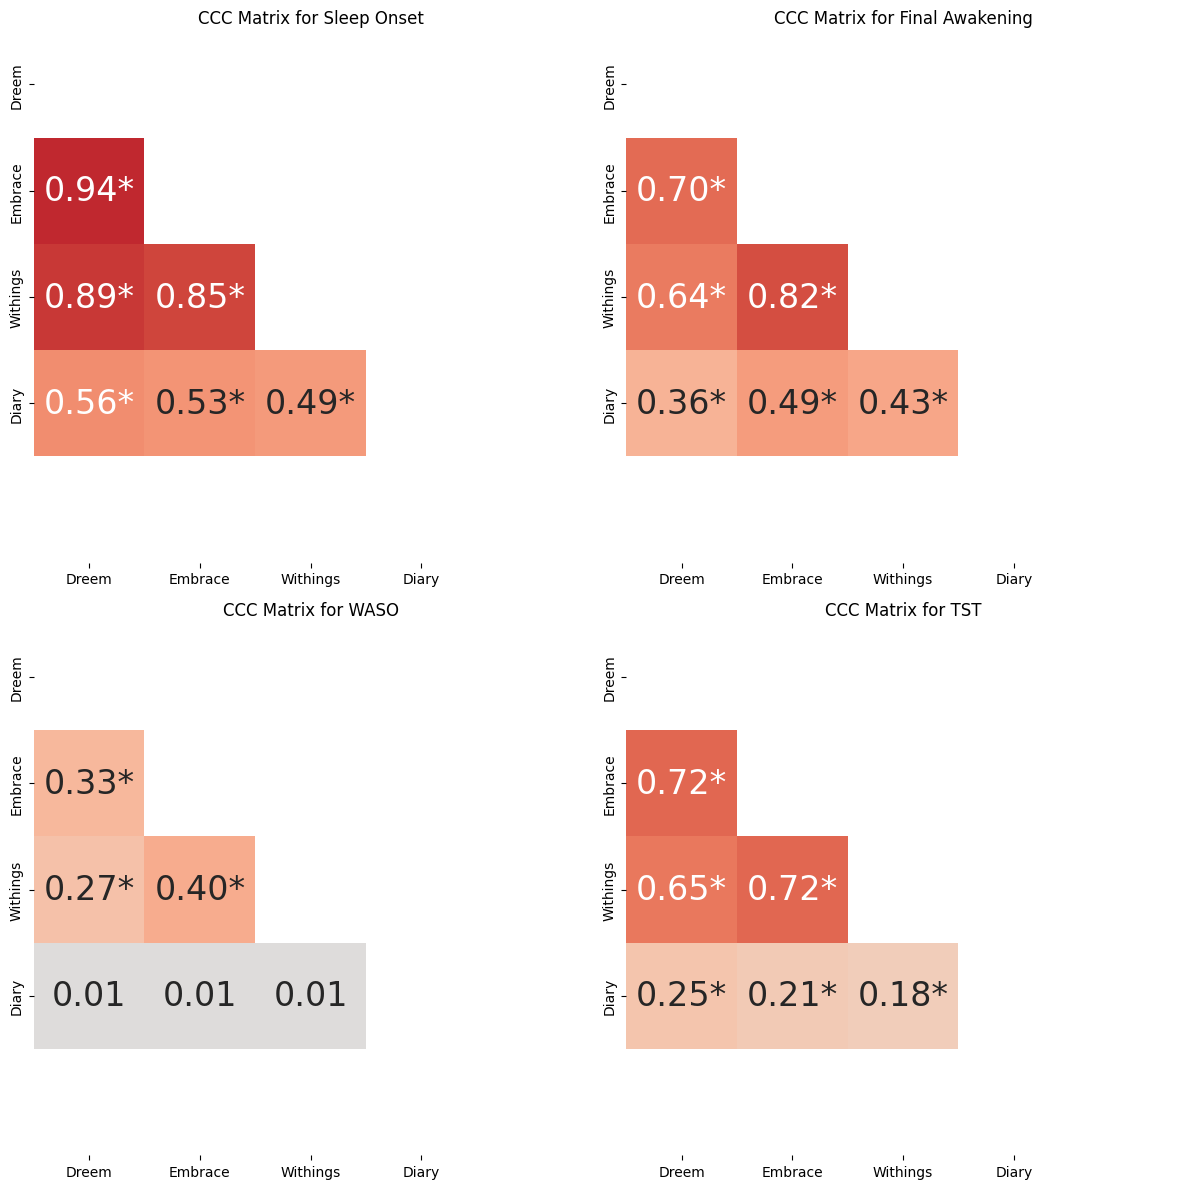

In [12]:
# List of measures and their corresponding DataFrames
measures = {
    "Sleep Onset": SO_pernight,
    "Final Awakening": FA_pernight,
    "WASO": WASO_pernight,
    "TST": TST_pernight
}

device_labels = ['Dreem', 'Embrace', 'Withings', 'Diary'] 

# Create heatmaps for each measure
plt.figure(figsize=(12, 12))  # Adjust figure size
for i, (measure, df) in enumerate(measures.items(), 1):
    # Initialize CCC matrix (3x3)
    n = df.shape[1]
    ccc_matrix = np.zeros((n, n))
    annotations = np.empty((n, n), dtype=object)  # Annotation matrix for significance
    
    # Calculate pairwise CCC
    for row in range(n):
        for col in range(n):
            if row != col:  # Avoid diagonal computation if not needed
                sig_thresh = random_ccc_percentile(df.iloc[:, row], df.iloc[:, col])
                # print(f"Significance threshold for {measure} between {device_labels[row]} and {device_labels[col]}: {sig_thresh:.2f}")
                ccc_value = concordance_correlation_coefficient(df.iloc[:, row], df.iloc[:, col])
                ccc_matrix[row, col] = ccc_value
                annotations[row, col] = f"{ccc_value:.2f}" + ("*" if abs(ccc_value) > sig_thresh else "")
            else:
                ccc_matrix[row, col] = 1.0  # Perfect agreement with itself
    
    # Expand to 4x4 with zeros in the extra row/column
    expanded_matrix = np.zeros((5, 5))
    expanded_annotations = np.full((5, 5), "", dtype=object)  # Expanded annotation matrix
    expanded_matrix[:4, :4] = ccc_matrix  # Copy the original 3x3 matrix
    expanded_annotations[:4, :4] = annotations  # Copy annotations
    
    # Create a mask to hide the upper triangle and the extra row/column
    mask = np.ones_like(expanded_matrix, dtype=bool)
    mask[:4, :4] = np.triu(np.ones_like(ccc_matrix, dtype=bool))  # Only top-left 3x3 block has values

    # Plot heatmap
    plt.subplot(2, 2, i)
    sns.heatmap(expanded_matrix, mask=mask, annot=expanded_annotations, cmap="coolwarm", cbar=False, 
                vmin=-1, vmax=1, fmt="", annot_kws={"size": 24},  # fmt="" since annotations are preformatted
                xticklabels=device_labels, yticklabels=device_labels)
    plt.title(f"CCC Matrix for {measure}")
    
# Adjust layout and show the plot
plt.tight_layout()
plt.show()

### Plot the CCC values for each sleep measure per subject

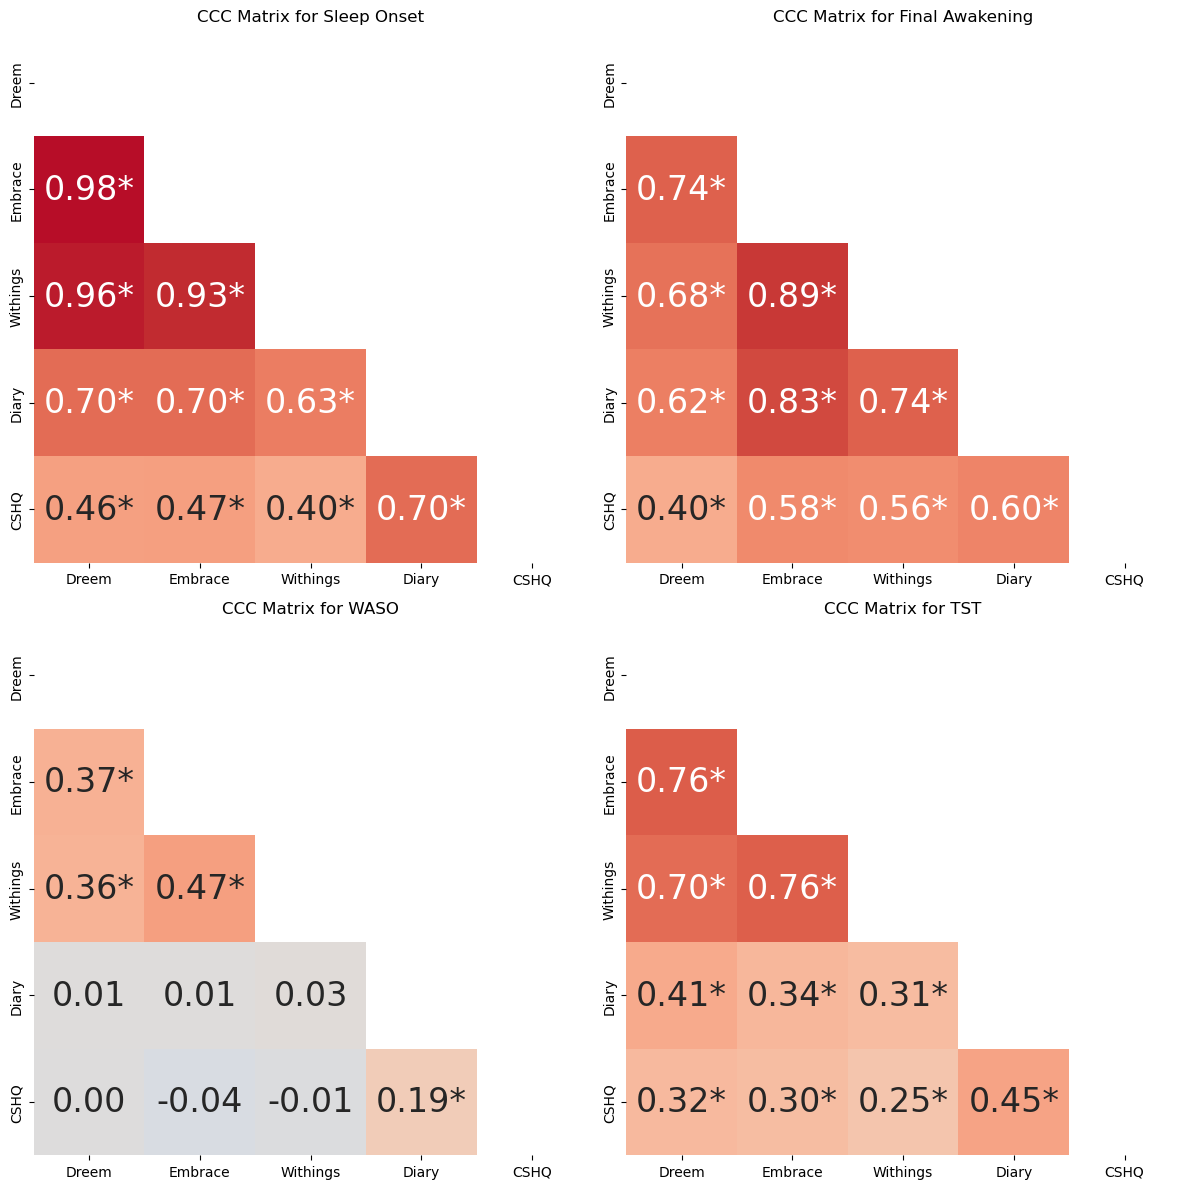

In [127]:
# List of measures and their corresponding DataFrames
measures = {
    "Sleep Onset": SO_bysub.drop('SPID',axis=1),
    "Final Awakening": FA_bysub.drop('SPID',axis=1),
    "WASO": WASO_bysub.drop('SPID',axis=1),
    "TST": TST_bysub.drop('SPID',axis=1)
}

device_labels = ['Dreem', 'Embrace', 'Withings', 'Diary', 'CSHQ'] 

# Create heatmaps for each measure
plt.figure(figsize=(12, 12))  # Adjust figure size
for i, (measure, df) in enumerate(measures.items(), 1):
    # Initialize CCC matrix
    n = df.shape[1]
    ccc_matrix = np.zeros((n, n))
    annotations = np.empty((n, n), dtype=object)  # Annotation matrix for significance
    
    # Calculate pairwise CCC
    for row in range(n):
        for col in range(n):
            if row != col:  # Avoid diagonal computation if not needed
                sig_thresh = random_ccc_percentile(df.iloc[:, row], df.iloc[:, col])
                # print(f"Significance threshold for {measure} between {device_labels[row]} and {device_labels[col]}: {sig_thresh:.2f}")
                ccc_value = concordance_correlation_coefficient(df.iloc[:, row], df.iloc[:, col])
                ccc_matrix[row, col] = ccc_value
                annotations[row, col] = f"{ccc_value:.2f}" + ("*" if abs(ccc_value) > sig_thresh else "")
            else:
                ccc_matrix[row, col] = 1.0  # Perfect agreement with itself
    
    # Create a mask to hide the upper triangle and diagonal
    mask = np.triu(np.ones_like(ccc_matrix, dtype=bool))
    
    # Plot heatmap
    plt.subplot(2, 2, i)
    sns.heatmap(ccc_matrix, mask=mask, annot=annotations, cmap="coolwarm", cbar=False, 
                vmin=-1, vmax=1, fmt="", annot_kws={"size": 24},
                xticklabels=device_labels, yticklabels=device_labels)
    plt.title(f"CCC Matrix for {measure}")
    

# Adjust layout and show the plot
plt.tight_layout()
plt.show()